This Colab notebook can be used for training and exporting any yolo models to ONNX format for further development into a TensorRT optimized engine for final deployment on any NVIDIA Jetson board for Edge-AI projects.

In [ ]:
!nvidia-smi

In [ ]:
!pip install ultralytics onnx onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 49.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 71.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 88.1 MB/s eta 0:00:00


In [ ]:
import os
import zipfile
import random
import shutil
from pathlib import Path

In [ ]:
zip_path = Path("/content/dataset.zip")
extract_root = Path("/content/data")

extract_root.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_root)

print("Extraction finished")

Extraction finished


In [ ]:
classes_files = list(Path("/content/data").rglob("classes.txt"))

if len(classes_files) == 0:
    raise RuntimeError("classes.txt not found in dataset")

dataset_root = classes_files[0].parent

print("Dataset root:", dataset_root)

Dataset root: /content/data


In [ ]:
classes_path = dataset_root / "classes.txt"

with open(classes_path) as f:
    classes = [c.strip() for c in f.readlines() if c.strip()]

print("Classes:", classes)

Classes: ['_attest', '_track', 'car', 'duck', 'person', 'traffic_sign']


In [ ]:
images_dir = dataset_root / "images"
labels_dir = dataset_root / "labels"

train_img = images_dir / "train"
val_img = images_dir / "val"

train_lbl = labels_dir / "train"
val_lbl = labels_dir / "val"

train_img.mkdir(parents=True, exist_ok=True)
val_img.mkdir(parents=True, exist_ok=True)
train_lbl.mkdir(parents=True, exist_ok=True)
val_lbl.mkdir(parents=True, exist_ok=True)

In [ ]:
image_files = [p for p in images_dir.glob("*") if p.is_file()]

random.shuffle(image_files)

split_idx = int(len(image_files) * 0.8)

train_files = image_files[:split_idx]
val_files = image_files[split_idx:]

def move(files, img_dst, lbl_dst):
    for img in files:
        label = labels_dir / (img.stem + ".txt")

        shutil.move(str(img), img_dst / img.name)

        if label.exists():
            shutil.move(str(label), lbl_dst / label.name)

move(train_files, train_img, train_lbl)
move(val_files, val_img, val_lbl)

print("Dataset split complete")

Dataset split complete


In [ ]:
yaml_path = Path("/content/dataset.yaml")

yaml_text = f"""
path: {dataset_root}
train: images/train
val: images/val

names:
"""

for i, name in enumerate(classes):
    yaml_text += f"  {i}: {name}\n"

with open(yaml_path, "w") as f:
    f.write(yaml_text)

print("dataset.yaml created")
print(yaml_text)

dataset.yaml created

path: /content/data
train: images/train
val: images/val

names:
  0: _attest
  1: _track
  2: car
  3: duck
  4: person
  5: traffic_sign



In [ ]:
from ultralytics import YOLO

model = YOLO("yolo26s.pt") #change this to whatever model you want to train. for example model = YOLO("yolov11s.pt")

model.train(
    data="/content/dataset.yaml",
    epochs=180,
    imgsz=256,
    batch=16,
    device=0
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=180, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=256, int8=False, 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7cf0e48f06b0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
        

In [ ]:
!pip install opencv-python

In [ ]:
!pip install ipywidgets --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 29.6 MB/s eta 0:00:00


✅ Model loaded: /content/runs/detect/train/weights/best.pt

Upload an image or video file...


Saving aux_frame_000196_jpg.rf.1b69b4b587e81671fd39c1dcc70cdf26.jpg to aux_frame_000196_jpg.rf.1b69b4b587e81671fd39c1dcc70cdf26.jpg

Detected file: aux_frame_000196_jpg.rf.1b69b4b587e81671fd39c1dcc70cdf26.jpg  |  Type: .jpg

image 1/1 /content/aux_frame_000196_jpg.rf.1b69b4b587e81671fd39c1dcc70cdf26.jpg: 192x256 1 car, 62.8ms
Speed: 0.8ms preprocess, 62.8ms inference, 0.7ms postprocess per image at shape (1, 3, 192, 256)

── Detections ──
  car: 0.86  bbox: [68.2, 13.3, 131.1, 65.7]

✅ Result saved to: /content/result_image.jpg


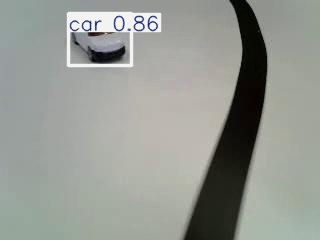

In [ ]:
import os, cv2, torch
import numpy as np
from ultralytics import YOLO
from google.colab import files
from IPython.display import display, Image as IPImage
import ipywidgets as widgets

# ── Config ──────────────────────────────────────────────────────────────────
BEST_PT = "/content/runs/detect/train/weights/best.pt"
IMGSZ   = 256
CONF    = 0.25

model = YOLO(BEST_PT)
print(f"✅ Model loaded: {BEST_PT}")

# ── Upload ───────────────────────────────────────────────────────────────────
print("\nUpload an image or video file...")
uploaded = files.upload()
input_path = list(uploaded.keys())[0]
ext = os.path.splitext(input_path)[-1].lower()

print(f"\nDetected file: {input_path}  |  Type: {ext}")

# ── Inference ────────────────────────────────────────────────────────────────
IMAGE_EXTS = ['.jpg', '.jpeg', '.png', '.bmp', '.webp', '.tiff']
VIDEO_EXTS = ['.mp4', '.avi', '.mov', '.mkv', '.gif']

if ext in IMAGE_EXTS:
    # ── Image ────────────────────────────────────────────────────────────────
    results = model.predict(
        source  = input_path,
        imgsz   = IMGSZ,
        conf    = CONF,
        device  = 0,
        save    = False,
        verbose = True,
    )

    annotated = results[0].plot()
    out_path  = "/content/result_image.jpg"
    cv2.imwrite(out_path, annotated)

    print(f"\n── Detections ──")
    for box in results[0].boxes:
        cls_id = int(box.cls)
        label  = model.names[cls_id]
        conf   = float(box.conf)
        xyxy   = box.xyxy[0].tolist()
        print(f"  {label}: {conf:.2f}  bbox: {[round(x,1) for x in xyxy]}")

    print(f"\n✅ Result saved to: {out_path}")
    display(IPImage(out_path))

elif ext in VIDEO_EXTS:
    # ── Video ────────────────────────────────────────────────────────────────
    cap     = cv2.VideoCapture(input_path)
    fps     = cap.get(cv2.CAP_PROP_FPS) or 25
    w       = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h       = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total   = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    out_path = "/content/result_video.mp4"

    writer = cv2.VideoWriter(
        out_path,
        cv2.VideoWriter_fourcc(*"mp4v"),
        fps, (w, h)
    )

    print(f"Processing {total} frames at {fps:.1f}fps...")
    frame_idx = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        results  = model.predict(
            source  = frame,
            imgsz   = IMGSZ,
            conf    = CONF,
            device  = 0,
            verbose = False,
        )
        annotated = results[0].plot()
        writer.write(annotated)
        frame_idx += 1

        if frame_idx % 50 == 0:
            print(f"  {frame_idx}/{total} frames done...")

    cap.release()
    writer.release()

    print(f"\n✅ Result saved to: {out_path}")
    files.download(out_path)

else:
    print(f"❌ Unsupported file type: {ext}")
    print(f"   Supported images : {IMAGE_EXTS}")
    print(f"   Supported videos : {VIDEO_EXTS}")

In [ ]:
!pip install onnx onnxsim onnxslim --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 62.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.9/235.9 kB 24.5 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

BEST_PT = "/content/runs/detect/train/weights/best.pt"
IMGSZ   = 256

model = YOLO(BEST_PT)

try:
    path = model.export(
        format   = "onnx",
        imgsz    = IMGSZ,
        opset    = 12,
        dynamic  = False,
        simplify = True,
        batch    = 1,
        device   = 0,
        end2end  = False,
    )
    print(f"✅ opset 12 succeeded: {path}")

except Exception as e:
    print("=" * 60)
    print("EXPORT FAILED at opset 12 — full error:")
    print("=" * 60)
    print(e)

    print("\nTrying default export to confirm minimum required opset...")
    try:
        path2 = model.export(
            format   = "onnx",
            imgsz    = IMGSZ,
            dynamic  = False,
            simplify = True,
            batch    = 1,
            device   = 0,
        )
        print(f"Default export succeeded: {path2}")
    except Exception as e2:
        print(f"Default export also failed: {e2}")

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26s summary (fused): 146 layers, 9,933,516 parameters, 0 gradients, 20.5 GFLOPs

PyTorch: starting from '/content/runs/detect/train/weights/best.pt' with input shape (1, 3, 256, 256) BCHW and output shape(s) (1, 10, 1344) (19.3 MB)

ONNX: starting export with onnx 1.20.1 opset 12...
ONNX: slimming with onnxslim 0.1.87...
ONNX: export success ✅ 1.9s, saved as '/content/runs/detect/train/weights/best.onnx' (36.3 MB)

Export complete (3.3s)
Results saved to /content/runs/detect/train/weights
Predict:         yolo predict task=detect model=/content/runs/detect/train/weights/best.onnx imgsz=256 
Validate:        yolo val task=detect model=/content/runs/detect/train/weights/best.onnx imgsz=256 data=/content/dataset.yaml  
Visualize:       https://netron.app
✅ opset 12 succeeded: /content/runs/detect/train/weights/best.onnx


In [ ]:
import onnx

ONNX_PATH = "/content/runs/detect/train/weights/best.onnx"

m = onnx.load(ONNX_PATH)
onnx.checker.check_model(m)

opset = m.opset_import[0].version
print(f"Exported opset  : {opset}")
print(f"TRT 8.2.1 max   : 13")
print(f"Nano compatible : {'✅ YES' if opset <= 13 else '❌ NO'}")

for inp in m.graph.input:
    print("IN  ", inp.name, [d.dim_value for d in inp.type.tensor_type.shape.dim])
for out in m.graph.output:
    print("OUT ", out.name, [d.dim_value for d in out.type.tensor_type.shape.dim])


Exported opset  : 12
TRT 8.2.1 max   : 13
Nano compatible : ✅ YES
IN   images [1, 3, 256, 256]
OUT  output0 [1, 10, 1344]
